# 🎬 Notebook 1 — Fusion, Nettoyage & Analyse Exploratoire
## Projet : Prédiction du succès commercial des films Bollywood

---

### 🗂️ Architecture du projet

```
projet/
├── Bollywood_Movies_data/
│   ├── indian_movies.csv          ← Dataset IMDB (50 000+ films, notes/votes/durée)
│   ├── Data_voting.csv            ← Dataset production (budget, revenue, genre, screens)
│   └── bollywood_merged_clean.csv ← OUTPUT de ce notebook
└── src/
    ├── 01_Fusion_Nettoyage_Analyse.ipynb   ← CE NOTEBOOK
    └── 02_Modelisation_Bollywood.ipynb
```

### 🔄 Pipeline de ce notebook

```
indian_movies.csv ──┐
                    ├──► Normalisation clé ──► JOIN (inner) ──► Sélection colonnes
Data_voting.csv  ──┘         titres                               ──► Nettoyage
                                                                       ──► Feature Eng.
                                                                           ──► Analyse EDA
                                                                               ──► Export CSV
```

### 📋 Résumé des étapes

| Étape | Action | Résultat attendu |
|-------|--------|------------------|
| 1 | Chargement des 2 datasets | DataFrames bruts |
| 2 | Normalisation clé de jointure | Titres lowercase, strip, sans ponctuation |
| 3 | Inner Join sur `Movie Name` | ~1790 films communs |
| 4 | Sélection des colonnes utiles | 11 variables pertinentes |
| 5 | Nettoyage (types, NaN, genres) | Données exploitables |
| 6 | Feature Engineering | `Profit(INR)`, `ROI` |
| 7 | Analyse Exploratoire (EDA) | Visualisations, distributions |
| 8 | Export | `bollywood_merged_clean.csv` |

---
## 1. 📦 Imports & Configuration des chemins

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Chemins relatifs depuis src/ ──────────────────────────────
BASE_DIR   = Path('..').resolve()
DATA_DIR   = BASE_DIR / 'Bollywood_Movies_data'

PATH_INDIAN = DATA_DIR / 'indian_movies.csv'
PATH_REPO   = DATA_DIR / 'Data_voting.csv'
OUTPUT_PATH = DATA_DIR / 'bollywood_clean.csv'

# ── Style graphique ───────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('✅ Imports OK')
print(f'📁 Dossier données : {DATA_DIR}')

✅ Imports OK
📁 Dossier données : C:\Users\piaay\OneDrive\ING4\SEMESTRE_2\ESTIMATION BAYESIENNE\Project-dePr-diction-du-genre-des-films-avec-Naive-Bayes\Bollywood_Movies_data


---
## 2. 📂 Chargement des datasets

> **`indian_movies.csv`** : scraping IMDB — contient notes, votes, durée, langue  
> **`Data_voting.csv`** : dataset production — contient budget, revenue, genre, écrans, période de sortie

In [16]:
df_indian = pd.read_csv(PATH_INDIAN)
df_voting = pd.read_csv(PATH_REPO)

print(f'🎬 indian_movies  : {df_indian.shape[0]:>6} films × {df_indian.shape[1]} colonnes')
print(f'🎬 Data_voting    : {df_voting.shape[0]:>6} films × {df_voting.shape[1]} colonnes')
print()
print('── Aperçu indian_movies ──')
display(df_indian.head(3))
print('── Aperçu Data_voting ──')
display(df_voting.head(3))

🎬 indian_movies  :  50602 films × 8 colonnes
🎬 Data_voting    :   1698 films × 14 colonnes

── Aperçu indian_movies ──


,ID,Movie Name,Year,Timing(min),Rating(10),Votes,Genre,Language
0,tt0398974,Dr. Shaitan,1960,-,-,-,-,hindi
1,tt1702558,Nadir Khan,1968,-,-,-,-,urdu
2,tt0493437,Apna Sapna Money Money,2006,134 min,5.3,"1,892","Comedy, Musical, Romance",hindi


── Aperçu Data_voting ──


,Movie Name,Release Period,Whether Remake,Whether Franchise,Genre,New Actor,New Director,New Music Director,Lead Star,Director,Music Director,Number of Screens,Revenue(INR),Budget(INR)
0,Golden Boys,Normal,No,No,suspense,Yes,No,No,Jeet Goswami,Ravi Varma,Baba Jagirdar,5,5000000,85000
1,Kaccha Limboo,Holiday,No,No,drama,Yes,No,Yes,Karan Bhanushali,Sagar Ballary,Amardeep Nijjer,75,15000000,825000
2,Not A Love Story,Holiday,No,No,thriller,No,No,No,Mahie Gill,Ram Gopal Verma,Sandeep Chowta,525,75000000,56700000


---
## 3. 🔑 Normalisation de la clé de jointure

La colonne `Movie Name` existe dans les deux fichiers mais avec des casses et espaces différents.  
On normalise : **lowercase + strip + suppression des caractères spéciaux**  
→ Objectif : maximiser le taux de correspondance lors du merge.

In [17]:
assert 'Movie Name' in df_indian.columns, '❌ Colonne Movie Name absente de indian_movies.csv'
assert 'Movie Name' in df_voting.columns, '❌ Colonne Movie Name absente de Data_voting.csv'

def normalize_title(s: pd.Series) -> pd.Series:
    return (s.astype(str)
             .str.lower()
             .str.strip()
             .str.replace(r'[^\w\s]', '', regex=True)
             .str.replace(r'\s+', ' ', regex=True))

df_indian['Movie Name'] = normalize_title(df_indian['Movie Name'])
df_voting['Movie Name'] = normalize_title(df_voting['Movie Name'])

print('✅ Normalisation des titres OK')

✅ Normalisation des titres OK


---
## 4. 🔗 Jointure (Inner Join)

On garde uniquement les films présents dans **les deux datasets** (`how='inner`).  
Les colonnes `Genre` existant dans les deux sources sont distinguées par les suffixes `_ind` / `_repo`  
→ on utilisera **`Genre_repo`** (catégorie métier plus propre).

In [18]:
df_merged = pd.merge(df_indian, df_voting, on='Movie Name', how='inner', suffixes=('_ind', '_repo'))
print(f'✅ Films après jointure : {df_merged.shape[0]} lignes × {df_merged.shape[1]} colonnes')
display(df_merged.head(3))

✅ Films après jointure : 1956 lignes × 21 colonnes


,ID,Movie Name,Year,Timing(min),Rating(10),Votes,Genre_ind,Language,Release Period,Whether Remake,...,Genre_repo,New Actor,New Director,New Music Director,Lead Star,Director,Music Director,Number of Screens,Revenue(INR),Budget(INR)
0,tt0493437,apna sapna money money,2006,134 min,5.3,"1,892","Comedy, Musical, Romance",hindi,Normal,No,...,comedy,No,No,No,Riteish Deshmukh,Sangeeth Sivan,Pritam,450,95000000,207325000
1,tt2930026,humraah the traitor,2008,-,-,-,Thriller,hindi,Normal,No,...,action,Yes,No,No,Dheren Kushesh Rusto,V.K. Singh,R.K. Pandit,15,7000000,205000
2,tt0250733,sikandar,1976,-,-,-,-,hindi,Holiday,No,...,thriller,Yes,No,No,Parzan Dastur,Piyush Jha,Sandesh Shandilya,250,50000000,8240000


---
## 5. 📌 Sélection des colonnes utiles

| Colonne | Source | Rôle |
|---------|--------|------|
| `Movie Name` | les deux | Identifiant |
| `Release Period` | Data_voting | Normal / Holiday |
| `Genre` | Data_voting | Catégorie du film |
| `New Music Director` | Data_voting | Nouveau musicien ? |
| `Number of Screens` | Data_voting | Distribution |
| `Revenue(INR)` | Data_voting | Variable clé |
| `Budget(INR)` | Data_voting | Variable clé |
| `Timing(min)` | indian_movies | Durée |
| `Rating(10)` | indian_movies | Note IMDB |
| `Votes` | indian_movies | Popularité IMDB |
| `Language` | indian_movies | Langue du film |

In [19]:
required_cols = [
    'Movie Name', 'Release Period', 'Genre_repo',
    'New Music Director', 'Number of Screens',
    'Revenue(INR)', 'Budget(INR)',
    'Timing(min)', 'Rating(10)', 'Votes', 'Language'
]

# Vérification
missing = [c for c in required_cols if c not in df_merged.columns]
if missing:
    print(f'⚠️  Colonnes manquantes : {missing}')
else:
    df_final = df_merged[required_cols].copy()
    df_final = df_final.rename(columns={'Genre_repo': 'Genre'})
    print(f'✅ Dataset réduit : {df_final.shape}')
    display(df_final.head(3))

✅ Dataset réduit : (1956, 11)


,Movie Name,Release Period,Genre,New Music Director,Number of Screens,Revenue(INR),Budget(INR),Timing(min),Rating(10),Votes,Language
0,apna sapna money money,Normal,comedy,No,450,95000000,207325000,134 min,5.3,"1,892",hindi
1,humraah the traitor,Normal,action,No,15,7000000,205000,-,-,-,hindi
2,sikandar,Holiday,thriller,No,250,50000000,8240000,-,-,-,hindi


---
## 6. 🧹 Nettoyage des données

### Problèmes observés dans le dataset brut :
- `Timing(min)` : chaîne `'134 min'` ou `'-'` → à convertir en float
- `Votes` : format `'1,892'` → à nettoyer avant conversion
- `Rating(10)`, `Budget(INR)`, `Revenue(INR)` : `'-'` → NaN
- Variables catégorielles : casse non homogène
- Genres redondants ou peu représentés : fusion ou suppression

### Genres fusionnés et supprimés :

| Action | Genres concernés |
|--------|------------------|
| Fusion → `romance` | `love story`, `lovestory`, `romcom`, `rom-com` |
| Suppression | `horror`, `masala`, `fantasy`, `suspense`, `adult`, `mythological` |

In [20]:
df_clean = df_final.copy()

# ── Remplacer '-' et variantes par NaN ────────────────────────
df_clean.replace(['-', '', ' ', 'nan'], np.nan, inplace=True)

# ── Timing(min) : supprimer ' min' et convertir ───────────────
df_clean['Timing(min)'] = (df_clean['Timing(min)']
                          .astype(str)
                          .str.replace('min', '', regex=False)
                          .str.strip())
df_clean['Timing(min)'] = pd.to_numeric(df_clean['Timing(min)'], errors='coerce')

# ── Votes : supprimer les virgules et convertir ───────────────
df_clean['Votes'] = (df_clean['Votes']
                      .astype(str)
                      .str.replace(',', '', regex=False)
                      .str.strip())
df_clean['Votes'] = pd.to_numeric(df_clean['Votes'], errors='coerce')

# ── Numériques restants ───────────────────────────────────────
for col in ['Rating(10)', 'Budget(INR)', 'Revenue(INR)', 'Number of Screens']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# ── Catégorielles : lowercase + strip ────────────────────────
for col in ['Release Period', 'Genre', 'New Music Director', 'Language']:
    df_clean[col] = (df_clean[col].astype(str)
                                   .str.lower()
                                   .str.strip()
                                   .replace('nan', np.nan))

# ── Fusion de genres proches ──────────────────────────────────
genres_to_merge = {
    'love story': 'romance', 'lovestory': 'romance',
    'love_story': 'romance',
    'romcom': 'romance',     'rom-com': 'romance',
    'rom__com': 'romance'
}
df_clean['Genre'] = df_clean['Genre'].replace(genres_to_merge)

# ── Suppression des genres peu pertinents ─────────────────────
genres_to_remove = ['horror', 'masala', 'fantasy', 'suspense', 'adult', 'mythological']
before = df_clean.shape[0]
df_clean = df_clean[~df_clean['Genre'].isin(genres_to_remove)].copy()
removed = before - df_clean.shape[0]

print(f'✅ Nettoyage terminé')
print(f'   Genres fusionnés : love story / lovestory / love_story / romcom / rom_com → romance')
print(f'   Lignes supprimées (genres retirés) : {removed}')

✅ Nettoyage terminé
   Genres fusionnés : love story / lovestory / love_story / romcom / rom_com → romance
   Lignes supprimées (genres retirés) : 182


---
## 7. 🔍 Analyse des valeurs manquantes

On supprime les lignes dont les variables **critiques pour le ML** sont manquantes.  
Les colonnes clés sont : `Genre`, `Timing(min)`, `Rating(10)`, `Votes`, `Language`, `Number of Screens`, `Revenue(INR)`, `Budget(INR)`.

In [21]:
# Rapport valeurs manquantes
missing_report = pd.DataFrame({
    'Manquants': df_clean.isna().sum(),
    '% Manquants': (df_clean.isna().mean() * 100).round(2)
}).sort_values('% Manquants', ascending=False)

print('── Rapport valeurs manquantes ──')
display(missing_report)

# Suppression des lignes avec valeurs manquantes sur colonnes critiques
critical_cols = ['Genre', 'Timing(min)', 'Rating(10)', 'Votes',
                  'Language', 'Number of Screens', 'Revenue(INR)', 'Budget(INR)']
before = df_clean.shape[0]
df_ml = df_clean.dropna(subset=critical_cols).copy()
after  = df_ml.shape[0]

print(f'\n✅ Lignes avant nettoyage : {before}')
print(f'   Lignes après dropna    : {after}')
print(f'   Lignes supprimées      : {before - after}')

── Rapport valeurs manquantes ──


,Manquants,% Manquants
Timing(min),368,20.74
Rating(10),247,13.92
Votes,247,13.92
Genre,0,0.00
Release Period,0,0.00
Movie Name,0,0.00
New Music Director,0,0.00
Budget(INR),0,0.00
Revenue(INR),0,0.00
Number of Screens,0,0.00



✅ Lignes avant nettoyage : 1774
   Lignes après dropna    : 1349
   Lignes supprimées      : 425


---
## 8. ⚙️ Feature Engineering

Deux indicateurs financiers sont calculés et seront utilisés comme **variables cibles** dans le Notebook 2 :

| Indicateur | Formule | Interprétation |
|------------|---------|----------------|
| `Profit(INR)` | Revenue − Budget | Gain absolu |
| `ROI` | Revenue / Budget | Rendement relatif (1.0 = équilibre) |

In [22]:
df_ml.loc[:, 'Profit(INR)'] = df_ml['Revenue(INR)'] - df_ml['Budget(INR)']
df_ml.loc[:, 'ROI']        = df_ml['Revenue(INR)'] / df_ml['Budget(INR)']

print('✅ Feature engineering OK')
display(df_ml[['Movie Name', 'Budget(INR)', 'Revenue(INR)', 'Profit(INR)', 'ROI']].head())

✅ Feature engineering OK


,Movie Name,Budget(INR),Revenue(INR),Profit(INR),ROI
0,apna sapna money money,207325000,95000000,-112325000,0.458218
3,sunday,319615000,220000000,-99615000,0.688328
4,red alert the war within,19300000,100000000,80700000,5.181347
5,highway,477065000,250000000,-227065000,0.524038
7,golmaal returns,800080000,350000000,-450080000,0.437456


---
## 9. 📊 Analyse Exploratoire (EDA)

> Ces visualisations seront présentées en **soutenance** pour justifier les choix de modélisation.

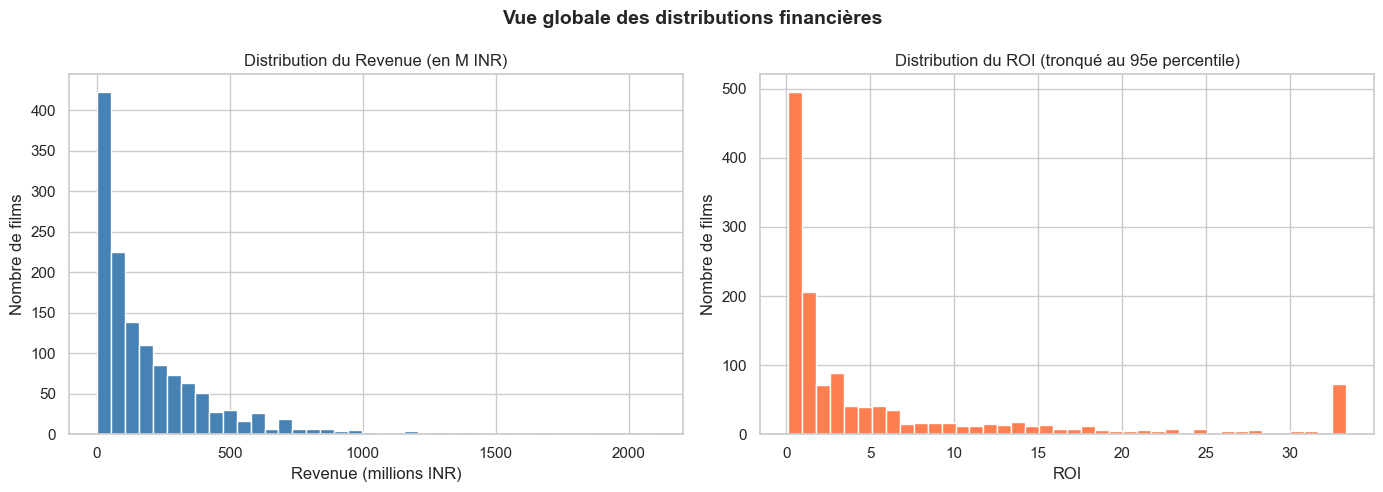

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution du Revenue
axes[0].hist(df_ml['Revenue(INR)'] / 1e6, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du Revenue (en M INR)')
axes[0].set_xlabel('Revenue (millions INR)')
axes[0].set_ylabel('Nombre de films')

# Distribution du ROI
roi_clip = df_ml['ROI'].clip(upper=df_ml['ROI'].quantile(0.95))
axes[1].hist(roi_clip, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribution du ROI (tronqué au 95e percentile)')
axes[1].set_xlabel('ROI')
axes[1].set_ylabel('Nombre de films')

plt.suptitle('Vue globale des distributions financières', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

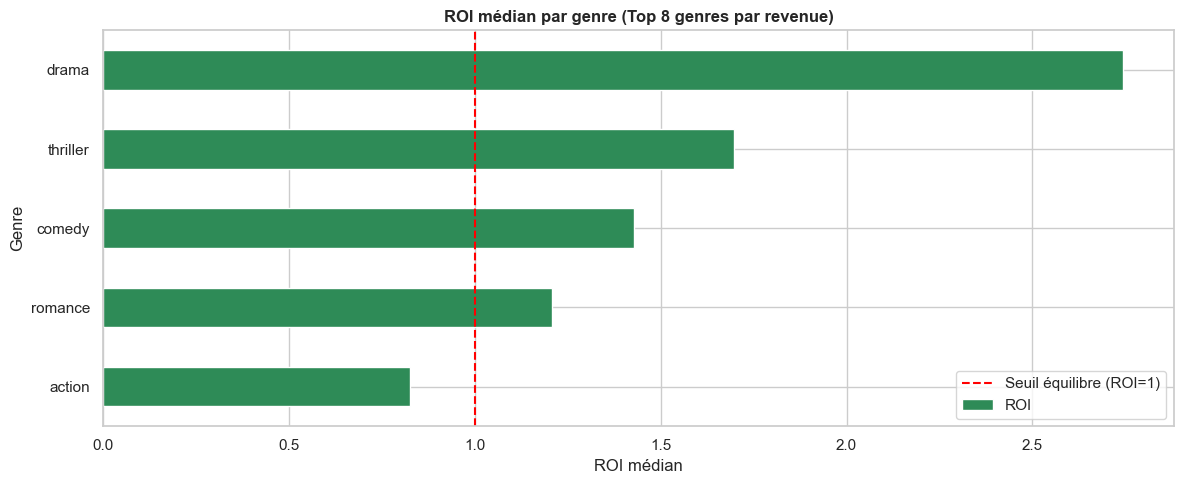


── Statistiques médianes par genre ──


,Revenue(INR),ROI,Votes
Genre,,,
action,410000000.0,0.825199,3693.5
romance,150000000.0,1.208642,1807.0
comedy,110000000.0,1.429472,814.5
thriller,110000000.0,1.697793,614.0
drama,75000000.0,2.743902,639.0


In [24]:
# ROI moyen par genre
genre_stats = (df_ml.groupby('Genre')[['Revenue(INR)', 'ROI', 'Votes']]
                     .median()
                     .sort_values('Revenue(INR)', ascending=False)
                     .head(8))

fig, ax = plt.subplots(figsize=(12, 5))
genre_stats['ROI'].sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('ROI médian par genre (Top 8 genres par revenue)', fontweight='bold')
ax.set_xlabel('ROI médian')
ax.axvline(1.0, color='red', linestyle='--', label='Seuil équilibre (ROI=1)')
ax.legend()
plt.tight_layout()
plt.show()

print('\n── Statistiques médianes par genre ──')
display(genre_stats)

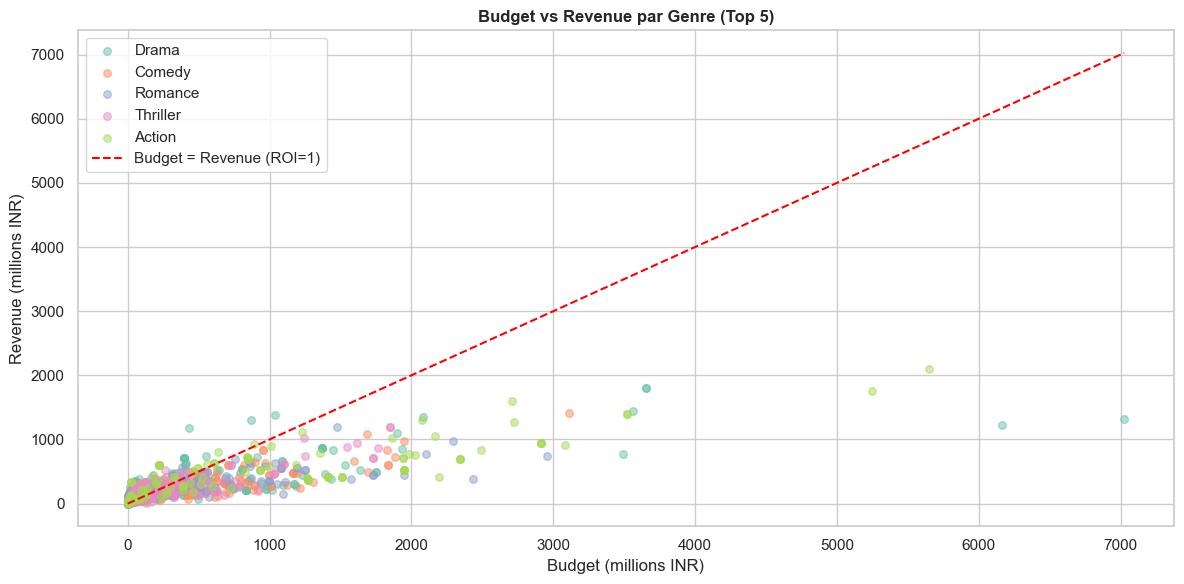

In [25]:
# Scatter Budget vs Revenue coloré par Genre
top_genres = df_ml['Genre'].value_counts().head(5).index.tolist()
df_plot = df_ml[df_ml['Genre'].isin(top_genres)].copy()

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('Set2', len(top_genres))
for i, genre in enumerate(top_genres):
    sub = df_plot[df_plot['Genre'] == genre]
    ax.scatter(sub['Budget(INR)'] / 1e6, sub['Revenue(INR)'] / 1e6,
               alpha=0.5, label=genre.capitalize(), color=palette[i], s=30)

# Ligne d'équilibre Budget = Revenue
max_val = max(df_plot['Budget(INR)'].max(), df_plot['Revenue(INR)'].max()) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', label='Budget = Revenue (ROI=1)')
ax.set_xlabel('Budget (millions INR)')
ax.set_ylabel('Revenue (millions INR)')
ax.set_title('Budget vs Revenue par Genre (Top 5)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

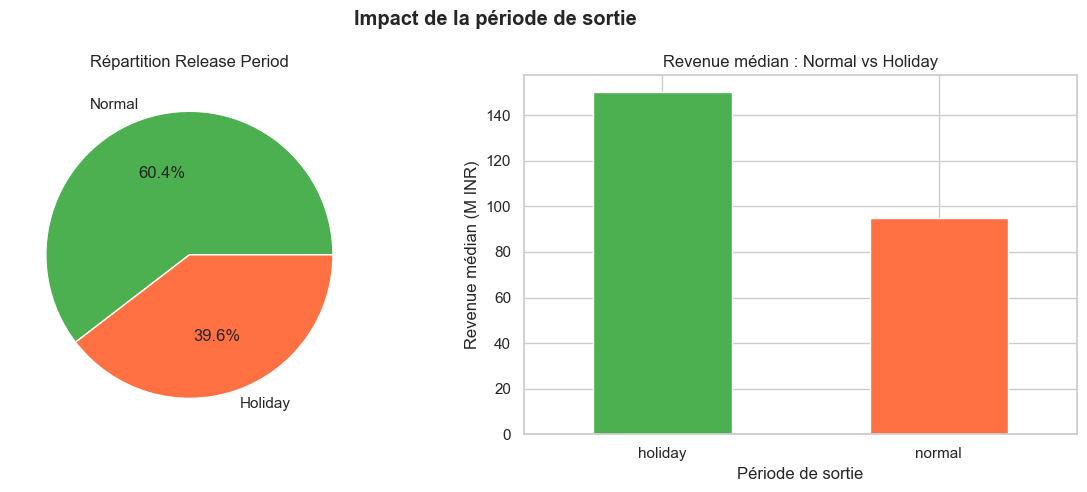

In [26]:
# Distribution par Release Period
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Répartition des films
df_ml['Release Period'].value_counts().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    colors=['#4CAF50', '#FF7043'],
    labels=['Normal', 'Holiday']
)
axes[0].set_title('Répartition Release Period')
axes[0].set_ylabel('')

# Revenue médian par période
df_ml.groupby('Release Period')['Revenue(INR)'].median().div(1e6).plot(
    kind='bar', ax=axes[1], color=['#4CAF50', '#FF7043'], edgecolor='white'
)
axes[1].set_title('Revenue médian : Normal vs Holiday')
axes[1].set_xlabel('Période de sortie')
axes[1].set_ylabel('Revenue médian (M INR)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Impact de la période de sortie', fontweight='bold')
plt.tight_layout()
plt.show()

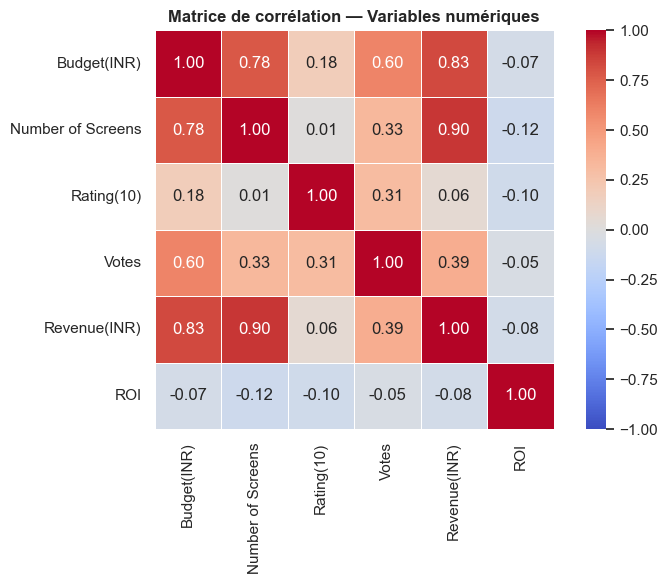


💡 Observations clés pour la soutenance :
   - Budget et Number of Screens sont fortement corrélés au Revenue
   - Le ROI est peu corrélé aux autres variables → variable cible intéressante
   - Rating et Votes ont une corrélation modérée entre eux


In [27]:
# Matrice de corrélation
num_cols = ['Budget(INR)', 'Number of Screens', 'Rating(10)', 'Votes', 'Revenue(INR)', 'ROI']
corr = df_ml[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation — Variables numériques', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Observations clés pour la soutenance :')
print('   - Budget et Number of Screens sont fortement corrélés au Revenue')
print('   - Le ROI est peu corrélé aux autres variables → variable cible intéressante')
print('   - Rating et Votes ont une corrélation modérée entre eux')

---
## 10. 💾 Export du dataset nettoyé

> Ce fichier `bollywood_merged_clean.csv` est **l'unique entrée** du Notebook 2.  
> Format final : **{nb_films} films × 13 colonnes** (sans l'index).

In [28]:
df_ml.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Export réussi → {OUTPUT_PATH}')  
print(f'   Shape finale : {df_ml.shape}')
print(f'   Colonnes     : {list(df_ml.columns)}')
print()
print('── Récapitulatif pour la soutenance ──')
print(f'   Films chargés (indian_movies)    : ~50 602')
print(f'   Films chargés (Data_voting)      :  1 698')
print(f'   Films après inner join           : ~1 790')
print(f'   Films après nettoyage final      :  {df_ml.shape[0]}')
print(f'   Variables pour ML                :  {df_ml.shape[1]}')

✅ Export réussi → C:\Users\piaay\OneDrive\ING4\SEMESTRE_2\ESTIMATION BAYESIENNE\Project-dePr-diction-du-genre-des-films-avec-Naive-Bayes\Bollywood_Movies_data\bollywood_clean.csv
   Shape finale : (1349, 13)
   Colonnes     : ['Movie Name', 'Release Period', 'Genre', 'New Music Director', 'Number of Screens', 'Revenue(INR)', 'Budget(INR)', 'Timing(min)', 'Rating(10)', 'Votes', 'Language', 'Profit(INR)', 'ROI']

── Récapitulatif pour la soutenance ──
   Films chargés (indian_movies)    : ~50 602
   Films chargés (Data_voting)      :  1 698
   Films après inner join           : ~1 790
   Films après nettoyage final      :  1349
   Variables pour ML                :  13
